# QuantRisk Forensic Data Analysis

This notebook performs a comprehensive forensic audit and exploratory analysis of synthetic financial transaction data to identify potential fraud patterns and systemic risks.

## Analysis Overview

The investigation follows a structured approach:
1. **Data Integrity Assessment**: Establish data quality and handle anomalies
2. **Statistical Distribution Analysis**: Understand normal transaction patterns
3. **Temporal Pattern Detection**: Identify time-based anomalies
4. **Fraud Pattern Investigation**: Deep dive into suspicious activities

## Phase 2: Forensic Data Audit & Exploratory Analysis
Before searching for systemic risk, we must establish data integrity. Financial ledgers are absolute; a negative transaction amount in a standard transfer ledger often indicates a system error or a reversed transaction that wasn't properly reconciled, not a valid behavioral data point.

## 1. Environment Setup and Library Imports

Importing essential data analysis and visualization libraries for forensic investigation.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading and Initial Inspection

Loading the synthetic client and transaction datasets to begin the forensic analysis.

In [49]:
clients_df = pd.read_csv('clients.csv')
clients_df.head()

,client_id,name,device_id,ip_address,onboarding_country
0,client_0000,User_Entity_0,DEV-99999,192.168.246.169,UK
1,client_0001,User_Entity_1,DEV-99686,192.168.12.175,AUS
2,client_0002,User_Entity_2,DEV-51812,192.168.129.81,USA
3,client_0003,User_Entity_3,DEV-14875,192.168.113.136,GER
4,client_0004,User_Entity_4,DEV-36476,192.168.52.154,FRA


In [50]:
### 2.1 Client Dataset Overview

Examining the client data structure to understand the entity profiles in our financial ecosystem.

SyntaxError: invalid syntax (3332907741.py, line 3)

In [51]:
ledger_df = pd.read_csv('ledger.csv', parse_dates=['timestamp'])
ledger_df.head()

,transaction_id,client_id,amount,timestamp,destination_country
0,TXN-003367,client_0750,151.62,2025-10-03 03:00:19,GER
1,TXN-012543,client_0274,16.63,2025-10-28 18:04:14,UK
2,TXN-019756,client_0029,51.63,2025-01-17 16:02:21,UK
3,TXN-029625,client_0111,54.03,2025-06-13 18:47:44,AUS
4,TXN-036538,client_0638,93.89,2025-03-04 13:34:18,CYP


print(f"Initial Ledger Records: {len(ledger_df)}")

In [52]:
duplicates = ledger_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## 3. Data Integrity Assessment

Before conducting any analysis, we must establish data integrity. Financial ledgers require absolute accuracy - any anomalies could indicate system errors or deliberate manipulation.

In [53]:
missing_times = ledger_df[ledger_df['timestamp'].isna()]
print(f"Number of rows with missing timestamps: {len(missing_times)}")
missing_times

Number of rows with missing timestamps: 5


,transaction_id,client_id,amount,timestamp,destination_country
27,TXN-029570,client_0819,166.50,NaT,AUS
10074,TXN-032200,client_0462,16.71,NaT,GER
27730,TXN-017682,client_0906,17.44,NaT,CYP
38762,TXN-045290,client_0463,569.48,NaT,PAN
44272,TXN-043353,client_0337,121.35,NaT,GER


### 3.1 Dataset Scale Assessment

First, let's understand the volume of transaction data we're working with.

No duplicates found, but 5 transactions with missing timestamps. They seem otherwise ok and are currently not within the scope of this analysis, so we will just delete them

### 3.2 Duplicate Transaction Detection

Checking for duplicate records which could indicate system glitches or data integrity issues.

In [54]:
ledger_df = ledger_df.dropna(subset=['timestamp'])
print(f"Number of rows after dropping rows with missing timestamps: {len(ledger_df)}")

Number of rows after dropping rows with missing timestamps: 50019


### 3.3 Missing Timestamp Analysis

Identifying transactions with missing timestamps, which could indicate data capture failures or system issues during transaction processing.

In [55]:
negative_amounts = ledger_df[ledger_df['amount'] < 0]
print(f"Number of rows with negative amounts: {len(negative_amounts)}")
print(f"Total negative amounts: {negative_amounts['amount'].sum()}")
negative_amounts.head()

Number of rows with negative amounts: 10
Total negative amounts: -1000.0


,transaction_id,client_id,amount,timestamp,destination_country
897,TXN-031352,client_0546,-100.0,2025-08-29 02:35:03,CYP
16342,TXN-044973,client_0688,-100.0,2025-05-26 00:07:10,FRA
16511,TXN-004443,client_0778,-100.0,2025-06-30 01:44:45,AUS
16894,TXN-022007,client_0116,-100.0,2025-05-29 06:16:55,CAN
18724,TXN-028404,client_0692,-100.0,2025-10-26 15:09:42,PAN


These could be system errors or chargebacks, but since they are minimal and not within the scope of this analysis, we will just delete them.

### 3.4 Data Cleaning Decision

**Analysis**: 5 transactions have missing timestamps but otherwise appear valid. Since temporal analysis is crucial for fraud detection, these records must be excluded to maintain analysis integrity.

In [56]:
ledger_df = ledger_df[ledger_df['amount'] > 0]
print(f"Cleaned Ledger Records: {len(ledger_df)}")

Cleaned Ledger Records: 50009


### 3.5 Negative Transaction Amount Analysis

Investigating negative transaction amounts, which in standard transfer ledgers typically indicate system errors, reversed transactions, or accounting irregularities.

### Baseline Distribution & Extreme Outliers
Human financial behavior is right-skewed. Most transactions are small, everyday purchases, with a long tail of massive transfers. Let's visualize this distribution and mathematically isolate the 99th percentile to understand what constitutes an "extreme" transfer in this ecosystem.

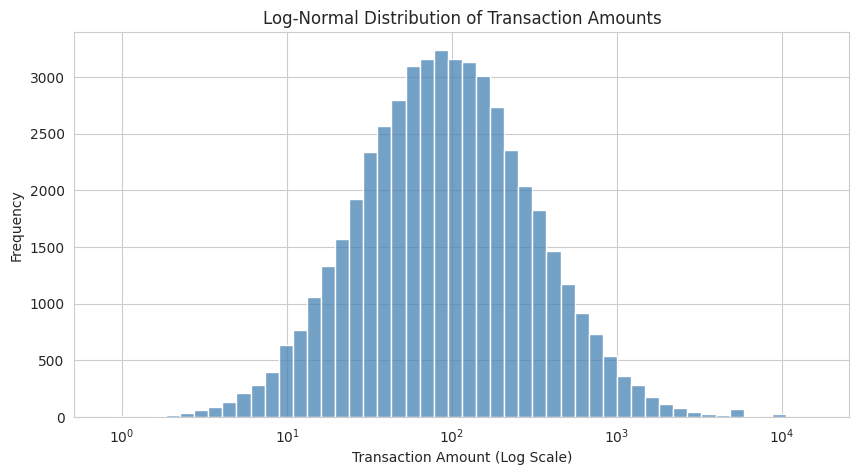

--- Distribution Metrics ---
Median Transaction: $90.27
99th Percentile Threshold: $1589.55
Total Extreme Transactions (>99th pct): 501


In [57]:
# Plotting the distribution on a log scale
plt.figure(figsize=(10, 5))
sns.histplot(ledger_df['amount'], bins=50, log_scale=True, color='steelblue')
plt.title('Log-Normal Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Frequency')
plt.show()

# Isolate the 99th Percentile
threshold_99 = ledger_df['amount'].quantile(0.99)
extreme_txns = ledger_df[ledger_df['amount'] > threshold_99]

print(f"--- Distribution Metrics ---")
print(f"Median Transaction: ${ledger_df['amount'].median():.2f}")
print(f"99th Percentile Threshold: ${threshold_99:.2f}")
print(f"Total Extreme Transactions (>99th pct): {len(extreme_txns)}")

### 3.6 Negative Amounts Treatment Decision

**Analysis**: 10 transactions show negative amounts totaling -$1,000. These could represent chargebacks or system errors, but for this forensic analysis focusing on fraud patterns, we'll exclude them to maintain data integrity.

### Temporal Frequency Analysis: Hunting for Determinism
Fraud often breaks the stochastic randomness of normal human behavior. Bots, automated structuring scripts, and layering protocols operate on rigid schedules. By mapping transaction volume across days and hours, we can look for localized breakdowns in randomness.

### 3.7 Data Cleaning Summary

After removing records with missing timestamps and negative amounts, we have a clean dataset of 50,009 transactions ready for forensic analysis.

In [58]:
ledger_df['day_of_week'] = ledger_df['timestamp'].dt.day_name()
ledger_df['hour'] = ledger_df['timestamp'].dt.hour
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ledger_df['day_of_week'] = pd.Categorical(ledger_df['day_of_week'], categories=days_order, ordered=True)
temporal_volume = ledger_df.groupby(['day_of_week', 'hour'], observed=False).size().unstack(fill_value=0)

## 4. Statistical Distribution Analysis

Understanding the baseline distribution of transaction amounts helps establish what constitutes "normal" behavior and identify extreme outliers that may warrant investigation.

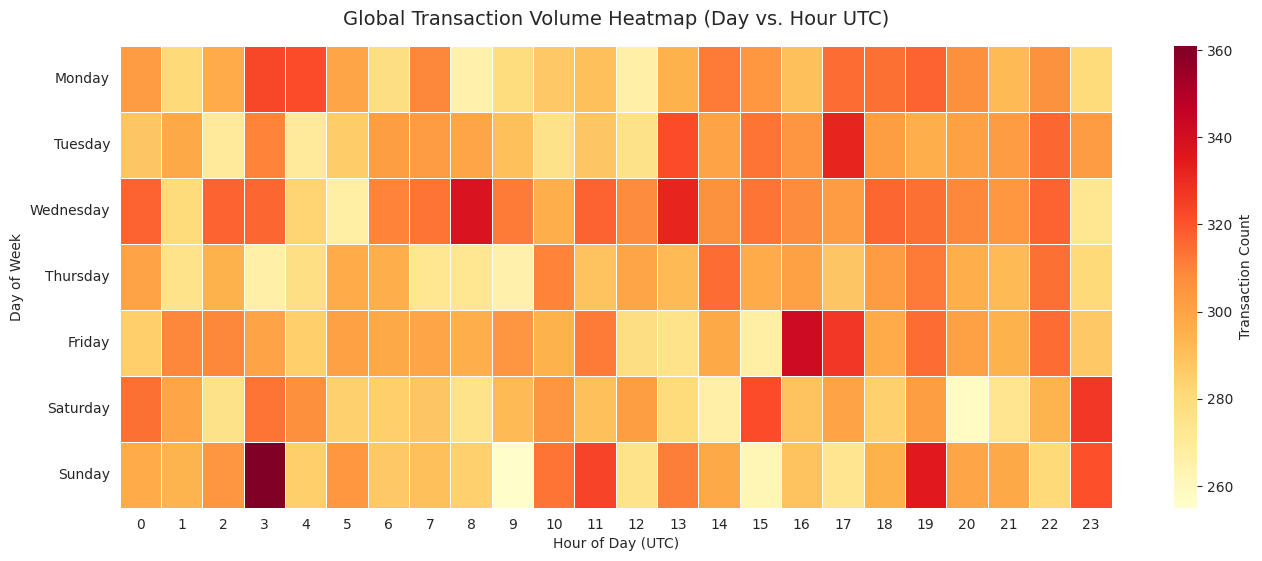

In [59]:
plt.figure(figsize=(16, 6))
sns.heatmap(temporal_volume, cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Transaction Count'})
plt.title('Global Transaction Volume Heatmap (Day vs. Hour UTC)', fontsize=14, pad=15)
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Day of Week')
plt.yticks(rotation=0)

plt.show()

### 4.1 Transaction Amount Distribution

Visualizing the log-normal distribution of transaction amounts and identifying the 99th percentile threshold to define "extreme" transactions.

Sunday 3 AM seems suspicious...

### 4.2 Distribution Analysis Results

**Key Findings**:
- Median transaction: $90.27 (typical small transaction)
- 99th percentile threshold: $1,589.55 (extreme transaction threshold)
- 501 transactions exceed the 99th percentile (potential high-risk transactions)

This right-skewed distribution is characteristic of normal human financial behavior - many small transactions with few large transfers.

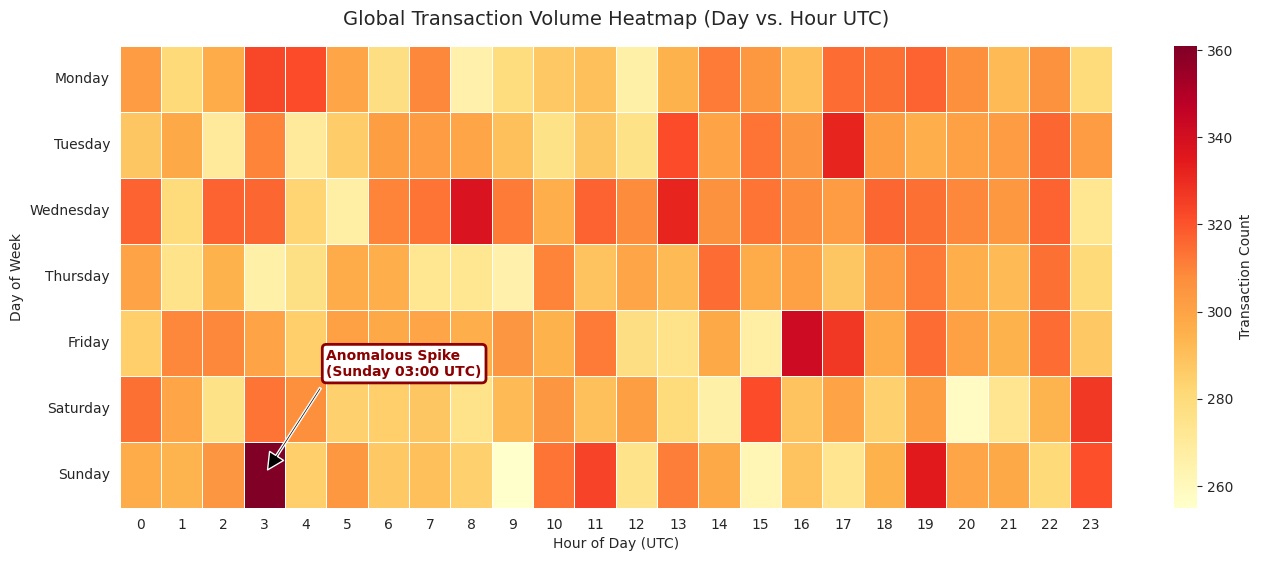

In [60]:
plt.figure(figsize=(16, 6))
sns.heatmap(temporal_volume, cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Transaction Count'})
plt.title('Global Transaction Volume Heatmap (Day vs. Hour UTC)', fontsize=14, pad=15)
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Day of Week')
plt.yticks(rotation=0)

plt.annotate('Anomalous Spike\n(Sunday 03:00 UTC)', 
             xy=(3.5, 6.5), xytext=(5, 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2))

plt.show()

## 5. Temporal Frequency Analysis

Fraudulent activities often break the natural randomness of human behavior. Automated scripts, bots, and structured fraud schemes operate on predictable schedules. By analyzing transaction patterns across time, we can identify these deterministic patterns.

In [61]:
sunday_3am = ledger_df[(ledger_df['day_of_week'] == 'Sunday') & (ledger_df['hour'] == 3)]
print("--- Profiling the Sunday 03:00 Anomaly ---")
print(f"Average Amount in Anomaly: ${sunday_3am['amount'].mean():.2f}")
print(f"Max Amount in Anomaly: ${sunday_3am['amount'].max():.2f}")

--- Profiling the Sunday 03:00 Anomaly ---
Average Amount in Anomaly: $981.38
Max Amount in Anomaly: $4995.00


### 5.1 Temporal Feature Engineering

Extracting day-of-week and hour features from timestamps to enable temporal pattern analysis.

### 5.2 Initial Temporal Heatmap

Creating a heatmap visualization of transaction volume across days and hours to identify patterns and anomalies.

### 5.3 Anomaly Detection

**Observation**: The heatmap reveals a suspicious spike in transaction activity at Sunday 3 AM UTC, which is unusual for normal human behavior patterns.

### 5.4 Annotated Heatmap

Enhanced heatmap with annotation highlighting the suspicious Sunday 3 AM activity pattern for clearer visualization.

## 6. Sunday 3 AM Anomaly Investigation

Deep dive into the suspicious transaction pattern detected at Sunday 3 AM UTC to understand its characteristics and potential fraud implications.

### 6.1 Anomaly Profiling

Analyzing the statistical characteristics of Sunday 3 AM transactions to determine if they represent coordinated fraudulent activity.

### 6.2 Anomaly Analysis Results

**Key Findings**:
- Average transaction amount: $981.38 (significantly higher than median of $90.27)
- Maximum transaction amount: $4,995.00 (well above 99th percentile threshold of $1,589.55)
- This pattern suggests automated, high-value transactions occurring at an unusual time

**Fraud Indicators**:
- Temporal clustering (Sunday 3 AM)
- Elevated transaction amounts
- Potential automated scheduling

This anomaly warrants further investigation as it matches known patterns of automated fraud schemes.